In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_burnout_dataset.csv to student_burnout_dataset.csv


In [ ]:
import pandas as pd
df = pd.read_csv("student_burnout_dataset.csv")
df.head()

,student_id,age,year_of_study,study_hours,sleep_hours,screen_time,physical_activity,subjects_count,assignments_per_week,academic_pressure,social_interaction,stress_level,motivation_level,study_life_balance,burnout_risk,burnout_level
0,1,23,3,9,7,3,1,4,4,2,3,2.05,3,6,Low,Low
1,2,21,4,12,9,3,2,7,2,2,7,1.65,8,4,Low,Low
2,3,23,3,6,3,10,2,7,3,4,7,2.80,3,9,Low,Low
3,4,21,2,9,5,5,1,6,4,5,4,3.55,3,8,Low,Low
4,5,20,3,12,9,3,5,7,5,10,5,4.40,3,5,Low,Low


In [ ]:
df.shape


(300, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            300 non-null    int64  
 1   age                   300 non-null    int64  
 2   year_of_study         300 non-null    int64  
 3   study_hours           300 non-null    int64  
 4   sleep_hours           300 non-null    int64  
 5   screen_time           300 non-null    int64  
 6   physical_activity     300 non-null    int64  
 7   subjects_count        300 non-null    int64  
 8   assignments_per_week  300 non-null    int64  
 9   academic_pressure     300 non-null    int64  
 10  social_interaction    300 non-null    int64  
 11  stress_level          300 non-null    float64
 12  motivation_level      300 non-null    int64  
 13  study_life_balance    300 non-null    int64  
 14  burnout_risk          300 non-null    object 
 15  burnout_level         3

In [ ]:
df.describe()

,student_id,age,year_of_study,study_hours,sleep_hours,screen_time,physical_activity,subjects_count,assignments_per_week,academic_pressure,social_interaction,stress_level,motivation_level,study_life_balance
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.00000,300.000000
mean,150.500000,20.566667,2.506667,7.800000,6.086667,5.986667,2.436667,5.533333,4.603333,6.066667,5.343333,3.170333,5.92000,5.496667
std,86.746758,1.765203,1.064770,2.973686,1.971152,2.519454,1.629367,1.131292,1.657855,2.571172,2.241026,1.293062,2.00841,2.324075
min,1.000000,18.000000,1.000000,3.000000,3.000000,2.000000,0.000000,4.000000,2.000000,2.000000,2.000000,1.000000,3.00000,2.000000
25%,75.750000,19.000000,2.000000,5.000000,4.000000,4.000000,1.000000,4.750000,3.000000,4.000000,3.000000,2.200000,4.00000,3.000000
50%,150.500000,21.000000,2.000000,8.000000,6.000000,6.000000,2.000000,6.000000,5.000000,6.000000,5.000000,3.075000,6.00000,6.000000
75%,225.250000,22.000000,3.000000,11.000000,8.000000,8.000000,4.000000,7.000000,6.000000,8.000000,7.000000,4.150000,8.00000,7.000000
max,300.000000,23.000000,4.000000,12.000000,9.000000,10.000000,5.000000,7.000000,7.000000,10.000000,9.000000,6.600000,9.00000,9.000000


In [ ]:
df.isnull().sum()

,0
student_id,0
age,0
year_of_study,0
study_hours,0
sleep_hours,0
screen_time,0
physical_activity,0
subjects_count,0
assignments_per_week,0
academic_pressure,0


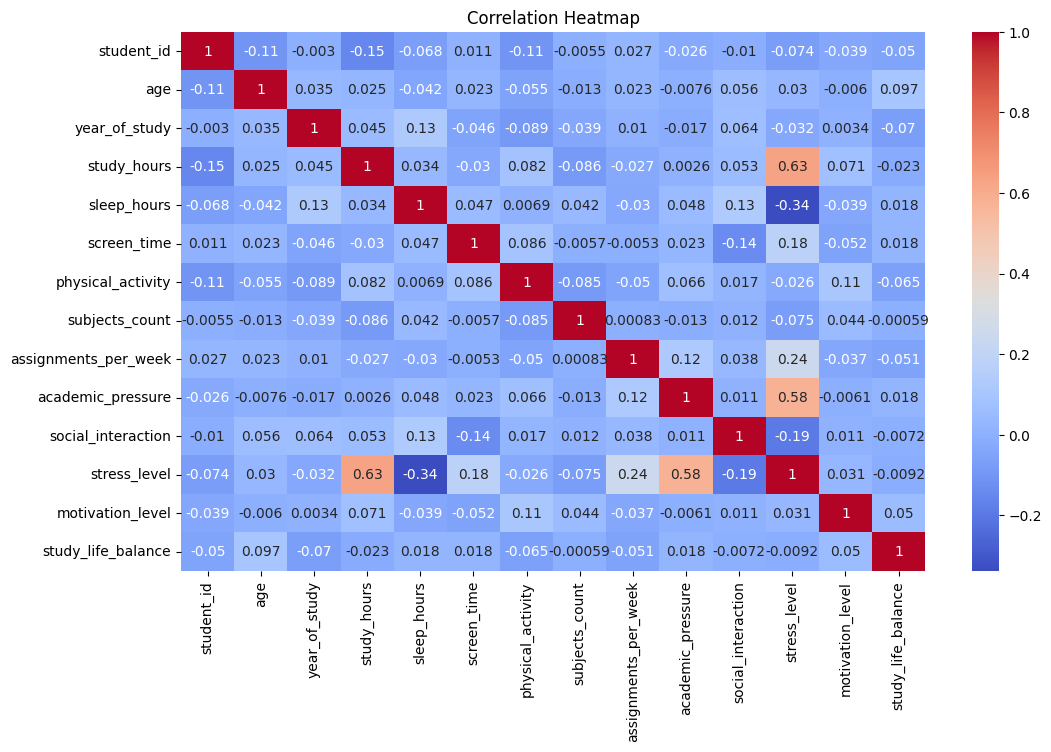

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

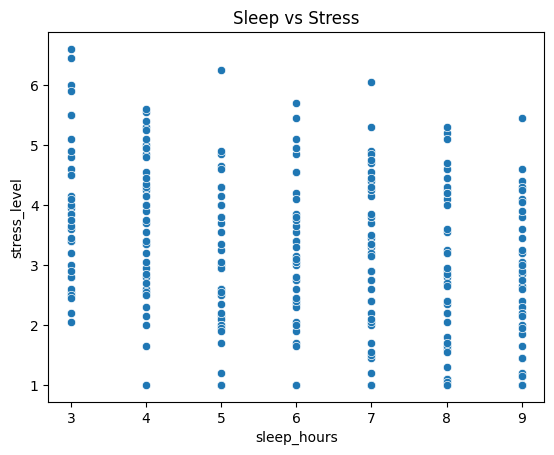

In [ ]:
sns.scatterplot(x="sleep_hours", y="stress_level", data=df)
plt.title("Sleep vs Stress")
plt.show()

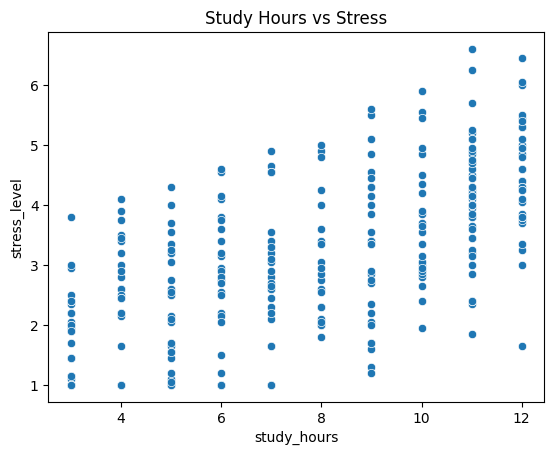

In [ ]:
sns.scatterplot(x="study_hours", y="stress_level", data=df)
plt.title("Study Hours vs Stress")
plt.show()

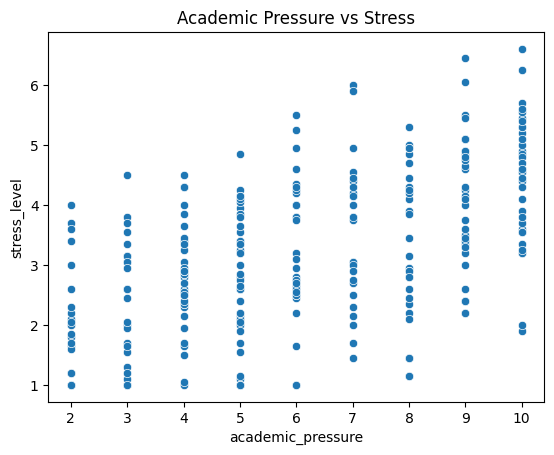

In [ ]:
sns.scatterplot(x="academic_pressure", y="stress_level", data=df)
plt.title("Academic Pressure vs Stress")
plt.show()

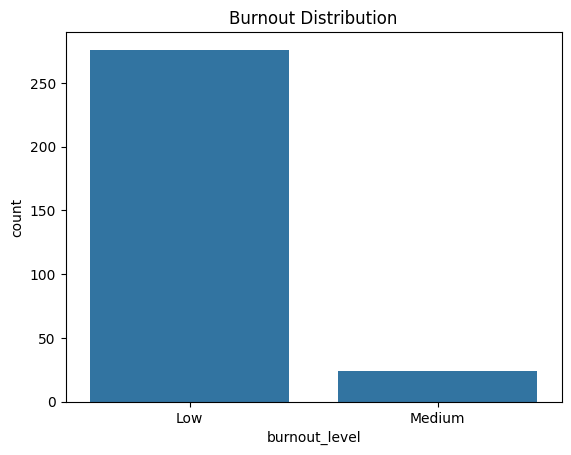

In [ ]:
sns.countplot(x="burnout_level", data=df)
plt.title("Burnout Distribution")
plt.show()

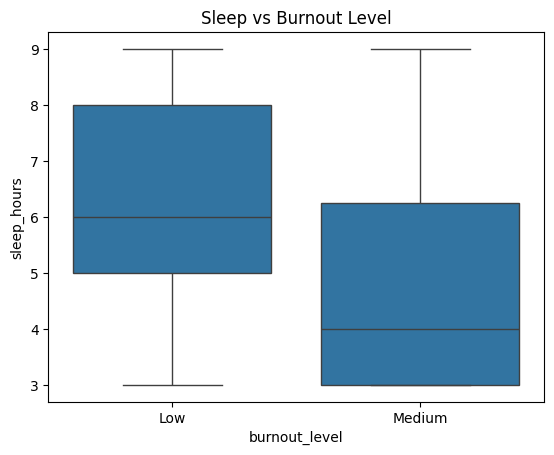

In [ ]:
sns.boxplot(x="burnout_level", y="sleep_hours", data=df)
plt.title("Sleep vs Burnout Level")
plt.show()

In [ ]:
df["risk_score"] = (
    df["stress_level"] * 0.6 +
    df["academic_pressure"] * 0.2 -
    df["sleep_hours"] * 0.2
)

In [ ]:
df["stress_level"].mean()

np.float64(3.1703333333333332)

In [ ]:
df['burnout_level'].value_counts(normalize=True).mul(100).reset_index()

,burnout_level,proportion
0,Low,92.0
1,Medium,8.0


In [ ]:
df.groupby("sleep_hours")["stress_level"].mean().reset_index()

,sleep_hours,stress_level
0,3,3.958571
1,4,3.751087
2,5,3.015909
3,6,3.248780
4,7,3.073333
5,8,2.835556
6,9,2.459091


In [ ]:
df.groupby("academic_pressure")["stress_level"].mean().reset_index()

,academic_pressure,stress_level
0,2,1.866667
1,3,2.298148
2,4,2.778947
3,5,2.767045
4,6,3.276562
5,7,3.516667
6,8,3.332759
7,9,4.012500
8,10,4.454054


In [ ]:
df["risk_category"].value_counts(normalize=True).mul(100).reset_index()

,risk_category,proportion
0,Medium,48.000000
1,Low,38.666667
2,High,13.333333


In [ ]:
df[df["risk_category"] == "High"].drop(columns=["student_id", "age","year_of_study"]).mean(numeric_only=True).sort_values(ascending=False)

,0
study_hours,9.6750
academic_pressure,9.0250
screen_time,6.5500
motivation_level,6.1250
study_life_balance,5.6500
subjects_count,5.4000
assignments_per_week,5.3500
stress_level,5.1675
social_interaction,4.7750
sleep_hours,4.6000


In [ ]:
df.to_csv("final_student_burnout_data.csv", index=False)


In [ ]:
from google.colab import files
files.download("final_student_burnout_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>